In [1]:
import json

In [2]:
filename = "records.json"
with open(filename, "r") as f:
    records = json.load(f)

In [3]:
not_none_count = {b: 0 for b in records["CoRT-SI"].keys()}
for key, value in records["CoRT-SI"].items():
    for v in value:
        if v is not None:
            not_none_count[key] += 1
not_none_count

{'5': 508, '24': 520, '25': 1394, '26': 743, '28': 628}

In [4]:
not_none_count = {b: 0 for b in records["CoRT-SI-oc"].keys()}
for key, value in records["CoRT-SI-oc"].items():
    for v in value:
        if v is not None:
            not_none_count[key] += 1
not_none_count

{'5': 564, '24': 578, '25': 832, '26': 735, '28': 659}

In [5]:
not_none_count = {b: 0 for b in records["DS"].keys()}
for key, value in records["DS"].items():
    for v in value:
        if v is not None:
            not_none_count[key] += 1
not_none_count

{'5': 636, '24': 506, '25': 816, '26': 651, '28': 552}

In [6]:
not_none_count = {b: 0 for b in records["Bonferroni"].keys()}
for key, value in records["Bonferroni"].items():
    for v in value:
        if v is not None:
            not_none_count[key] += 1
not_none_count

{'5': 125, '24': 125, '25': 614, '26': 280, '28': 225}

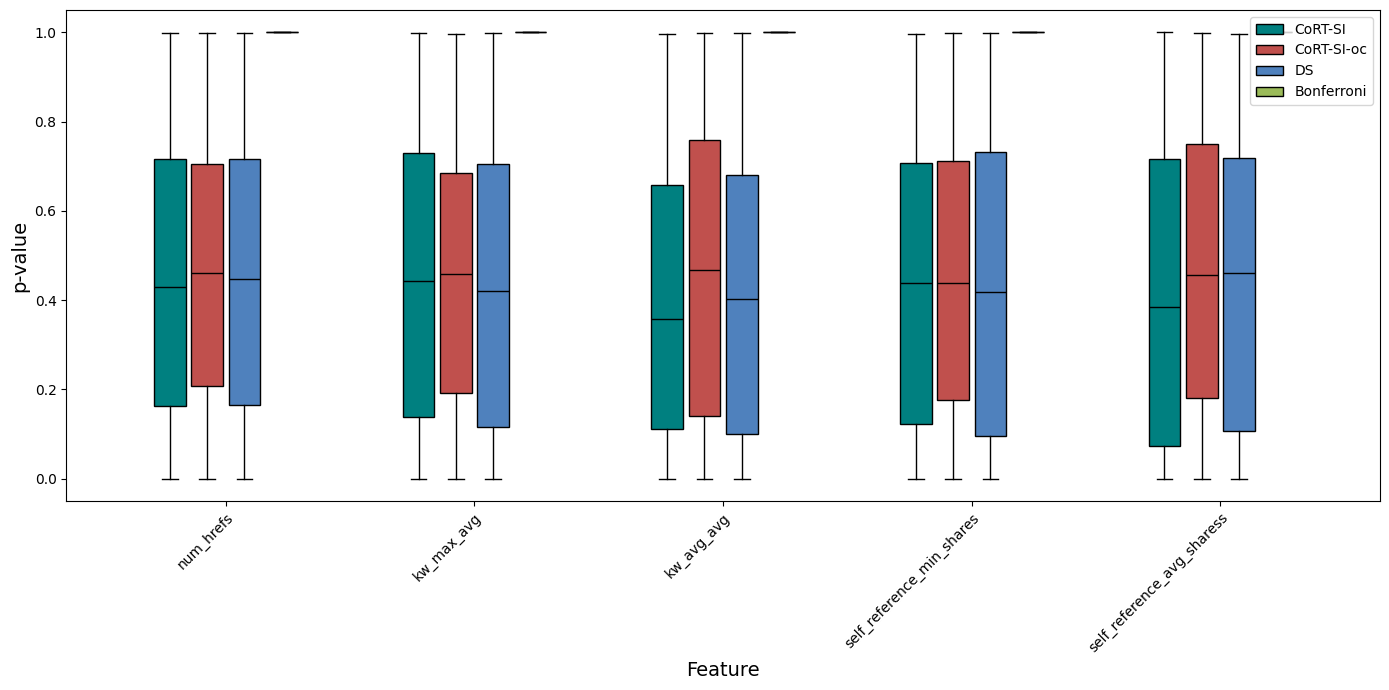

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Assuming 'records' is defined as per your data structure
methods = list(records.keys())
features = list(records[methods[0]].keys())
feature_names = ["num_hrefs", "kw_max_avg", "kw_avg_avg", "self_reference_min_shares", "self_reference_avg_sharess"]

# Choice 1: Modern Research Palette
colors = ['#008080', '#C0504D', '#4F81BD', '#9BBB59'] 

fig, ax = plt.subplots(figsize=(14, 7))

num_methods = len(methods)
num_features = len(features)

width = 0.18 
spacing = 1.2

for i, method in enumerate(methods):
    # Note: Ensure records contains enough data for [:500] slicing
    method_data = [records[method][feat][:500] for feat in features]
    
    positions = np.arange(num_features) * spacing + (i - (num_methods - 1) / 2) * width
    
    ax.boxplot(method_data, 
               positions=positions, 
               widths=width * 0.85, 
               patch_artist=True,
               showfliers=False,  
               boxprops=dict(facecolor=colors[i % len(colors)], color="black"),
               capprops=dict(color="black"),
               whiskerprops=dict(color="black"),
               medianprops=dict(color="black"))

# Formatting
ax.set_xticks(np.arange(num_features) * spacing)

# FIX: Added rotation_mode='anchor' and ha='right' to align the text end to the tick
ax.set_xticklabels(feature_names, rotation=45, ha='right', rotation_mode='anchor')

ax.set_ylabel('p-value', fontsize=14)
ax.set_xlabel('Feature', fontsize=14)
ax.set_ylim(-0.05, 1.05) 

# Legend
legend_elements = [Patch(facecolor=colors[i % len(colors)], edgecolor='black', label=methods[i]) 
                   for i in range(num_methods)]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save as PDF
plt.savefig("p_value_distribution.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [14]:
import os
import pandas as pd

data_filename ="OnlineNewsPopularity.csv"
df = pd.read_csv(data_filename)
df = df.drop(columns=["url", " timedelta"])

In [21]:
df.columns[28]

' self_reference_avg_sharess'

In [17]:
df.columns

Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sentiment_polarity', ' gl